# Tutorial: COLIBRE-SKIRT pipeline

This tutorial covers the creation of synthetic observables for galaxies from the [COLIBRE](https://colibre.strw.leidenuniv.nl/) simulations using the [SKIRT](https://skirt.ugent.be/root/_home.html) radiative transfer code. The notebook runs through the following steps:
- 1: Identify a single COLIBRE galaxy from a specific simulation and redshift for SKIRT radiative transfer postprocessing.
- 2: For this specific COLIBRE galaxy, extract the relevant particle data for the SKIRT radiative transfer simulation. This requires interfacing with the COLIBRE data, which is stored on the cosma8 machine.
- 3: Adjust the SKIRT configuration file to specify the radiative transfer configuration. SKIRT can then be run on any machine where the code is installed to generate the synthetic observables.

The example setup shown here largely follows the COLIBRE-SKIRT pipeline described in Gebek et al. 2026. This tutorial illustrates the workflow for a single galaxy. Most applications will require postprocessing many galaxies, which necessitates streamlined workflows on high-performance computers. Such an example workflow is shown in the [workflow_hpc](./workflow_hpc/) directory.

# Prerequisites

For steps 1 & 2, you will need an account on cosma8 to access the COLIBRE data. We will use the [swiftsimio](https://github.com/swiftsim/swiftsimio) and [swiftgalaxy](https://github.com/SWIFTSIM/swiftgalaxy) package to interface with the COLIBRE data. An introductory notebook for the COLIBRE data can be found [here](https://github.com/robjmcgibbon/COLIBRE_Introduction/tree/main). On cosma8, you will need the following python packages:
- unyt
- numpy
- matplotlib
- swiftsimio
- swiftgalaxy

The full conda environment used to run this notebook on cosma8 can be found in the cosma_env.yml file.

For step 3, you will need to install SKIRT on a machine of your choice. Follow the installation instructions of the SKIRT [website](https://skirt.ugent.be/root/_installation_guide.html). Before running SKIRT, make sure you understand the basics of the code, e.g. by running through some of the tutorials on the SKIRT [website](https://skirt.ugent.be/root/_user_guide.html).

## 1: Galaxy identification

In [1]:
import unyt
import numpy as np
from swiftsimio import load as load_snapshot
import matplotlib.pyplot as plt
from swiftgalaxy import SWIFTGalaxy, SOAP
from swiftsimio.visualisation.smoothing_length.generate import generate_smoothing_lengths as gsl

In [2]:
dataPath = '/cosma8/data/dp004/colibre/Runs/' # Path to COLIBRE data on cosma8 machine

Specify the simulation. In this tutorial, we will use the 25-Mpc box with thermal AGN feedback at m6 resolution at $z=0$.

In [3]:
simL = 25 # Box length in Mpc
simR = 6 # Mass resolution in log10(M/Msun)
simName = 'Thermal' # Simulation name
z = 0. # Redshift of snapshot to load

In [4]:
sim = 'L{:03.0f}_m{:01.0f}'.format(simL, simR)     # Define the simulation box
simPath = dataPath + sim + '/' + simName + '/'
print('Full path to simulation:', simPath)

Full path to simulation: /cosma8/data/dp004/colibre/Runs/L025_m6/Thermal/


Get the snapshot number corresponding to the requested redshift:

In [5]:
z_list = np.loadtxt(simPath + 'output_list.txt', delimiter = ',', usecols = 0)     # Load the redshifts of the available snapshots

if np.isin(z, z_list):
    snap = np.argwhere(z_list==z)[0,0]
    print('z = {:02.2f} --> snapshot {:04d}'.format(z, snap))
elif z > 0:
    snap = np.argmin(abs(z_list-z))
    print('z = {:02.2f} snapshot not available --> redirecting to snapshot {:04d}, corresponding to z = {:02.2f}'.format(z, snap, z_list[snap]))
else:
    raise ValueError('Illegal redshift: z = {:02.2f}'.format(z))

z = 0.00 --> snapshot 0127


Load the SOAP catalogue with galaxy properties:

In [6]:
catalogue_file = '{simPath}/SOAP-HBT/halo_properties_{snap_nr:04d}.hdf5'.format(simPath = simPath, snap_nr = snap)
catalogue = load_snapshot(catalogue_file)

Get some interesting galaxy properties (in this case, total gravitationally bound stellar mass/dust mass):

In [7]:
# Convert everything from comoving to physical units, and use unyt arrays instead of cosmo arrays
Mdust_galaxies = unyt.unyt_array(catalogue.bound_subhalo.dust_mass.to_physical().to('Msun'))
Mstar_galaxies = unyt.unyt_array(catalogue.bound_subhalo.stellar_mass.to_physical().to('Msun'))

Plot the dust mass as a function of stellar mass:

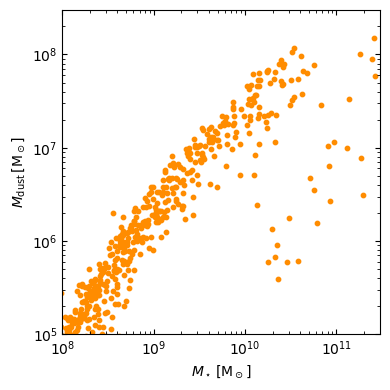

In [8]:
fig = plt.figure(figsize = (4., 4.))
ax = fig.add_subplot(111)

ax.scatter(Mstar_galaxies, Mdust_galaxies, s = 10., color = 'darkorange')

ax.set_xlim(1e8, 3e11)
ax.set_ylim(1e5, 3e8)

ax.set_xlabel(r'$M_\star\,[\mathrm{M}_\odot]$')
ax.set_ylabel(r'$M_{\mathrm{dust}}\,[\mathrm{M}_\odot]$')

ax.set_xscale('log')
ax.set_yscale('log')

ax.minorticks_on()
ax.tick_params(which = 'both', direction = 'in', top = True, right = True)

plt.tight_layout()
plt.show()
plt.close()


Select a single massive, dusty galaxy:

In [9]:
SEL = (Mstar_galaxies > unyt.unyt_quantity(5e9, 'Msun')) & (Mstar_galaxies < unyt.unyt_quantity(1e10, 'Msun')) & (Mdust_galaxies > unyt.unyt_quantity(1e7, 'Msun'))

print(np.sum(SEL), 'galaxies in this selection.')


halo_IDs = catalogue.input_halos.halo_catalogue_index

ID_galaxy = halo_IDs[SEL][0] # Take the first galaxy in the selection as an example
print('Example galaxy halo ID:', ID_galaxy.value)

idx_galaxy = np.argwhere(halo_IDs == ID_galaxy)[0][0] # Get the index of this galaxy in the catalogue, which is needed to access its properties
# Generally not the same as the halo ID!
print('Example galaxy positional index in the catalogue:', idx_galaxy)

22 galaxies in this selection.
Example galaxy halo ID: 1694
Example galaxy positional index in the catalogue: 4602


Print some properties of this example galaxy:

In [10]:
Mstar_galaxy = Mstar_galaxies[idx_galaxy]
Mdust_galaxy = Mdust_galaxies[idx_galaxy]
SFR_galaxy = catalogue.bound_subhalo.star_formation_rate[idx_galaxy].to_physical().to('Msun/yr')
Rstar_galaxy = catalogue.bound_subhalo.half_mass_radius_stars[idx_galaxy].to_physical().to('kpc')
Rdust_galaxy = catalogue.bound_subhalo.half_mass_radius_dust[idx_galaxy].to_physical().to('kpc')

print('Example galaxy stellar mass (log10):', np.log10(Mstar_galaxy.value))
print('Example galaxy dust mass (log10):', np.log10(Mdust_galaxy.value))
print('Example galaxy dust-to-stellar mass ratio:', (Mdust_galaxy / Mstar_galaxy).value)
print('Example galaxy star-formation rate:', SFR_galaxy)
print('Example galaxy specific star-formation rate:', SFR_galaxy / Mstar_galaxy)
print('Example galaxy stellar half-mass radius:', Rstar_galaxy)
print('Example galaxy dust half-mass radius:', Rdust_galaxy)

Example galaxy stellar mass (log10): 9.900858
Example galaxy dust mass (log10): 7.1652255
Example galaxy dust-to-stellar mass ratio: 0.0018380943
Example galaxy star-formation rate: 0.4825934 Msun/yr (Physical)
Example galaxy specific star-formation rate: 6.0635046e-11 1/yr (Physical)
Example galaxy stellar half-mass radius: 3.40271 kpc (Physical)
Example galaxy dust half-mass radius: 3.9978027 kpc (Physical)


## 2: Particle extraction

For the galaxy identified in step 1, extract now the relevant particle data and store it in .txt files that conform to SKIRT's requirements. We will use swiftgalaxy for this task. An introductory notebook on how to use swiftgalaxy on COLIBRE data can be found [here](https://github.com/SWIFTSIM/swiftgalaxy/blob/main/examples/SWIFTGalaxy_Colibre_QuickStart.ipynb).

In [11]:
virtual_snapshot_file = simPath + '/SOAP-HBT/colibre_with_SOAP_membership_{:04d}.hdf5'.format(snap)
sg = SWIFTGalaxy(virtual_snapshot_file, SOAP(catalogue_file, soap_index = idx_galaxy))

Get the relevant quantities for the gravitationally bound star particles. Note that swiftgalaxy automatically centers the galaxy!

In [12]:
stars_coordinates = unyt.unyt_array(sg.stars.coordinates.to_physical().to('pc'))
stars_ages = unyt.unyt_array(sg.stars.ages.to_physical().to('yr'))
stars_Z = unyt.unyt_array(sg.stars.metal_mass_fractions)
stars_Minit = unyt.unyt_array(sg.stars.initial_masses.to_physical().to('Msun'))
stars_h_fromGas = unyt.unyt_array(sg.stars.smoothing_lengths.to_physical().to('pc')) * 2.018932
# Based on neighbouring gas particles. Include factor to convert from COLIBRE to SKIRT smoothing length convention
stars_h_fromStars = unyt.unyt_array(gsl((sg.stars.coordinates + sg.centre) % sg.metadata.boxsize, sg.metadata.boxsize,
                        kernel_gamma = 1.0, neighbours = 32, speedup_fac = 1, dimension = 3).to('pc').to_physical()) 
# Distance to 32-nearest grav. bound star particle
stars_rhoBirth = unyt.unyt_array(sg.stars.birth_densities.to_physical().to('Msun/pc**3'))

print(len(stars_ages), 'star particles in this galaxy.')

6035 star particles in this galaxy.


Similarly, get all the relevant quantities for the graviationally bound gas particles:

In [13]:
gas_coordinates = unyt.unyt_array(sg.gas.coordinates.to_physical().to('pc'))
gas_Z = unyt.unyt_array(sg.gas.metal_mass_fractions)
DustSpecies = sg.gas.dust_mass_fractions.named_columns
gas_fDust = np.array([getattr(sg.gas.dust_mass_fractions, name) for name in DustSpecies]).T
gas_M = unyt.unyt_array(sg.gas.masses.to_physical().to('Msun'))
gas_Mdust = (gas_fDust * np.atleast_1d(gas_M)[:, np.newaxis].repeat(6, axis = 1)).to('Msun')
gas_SFR_10Myr = unyt.unyt_array(sg.gas.averaged_star_formation_rates[:, 1].to_physical().to('Msun/yr'))
# SFR averaged over 10 Myr
gas_h = unyt.unyt_array(sg.gas.smoothing_lengths.to_physical().to('pc')) * 2.018932 # Convert from COLIBRE to SKIRT smoothing length convention

print(len(gas_M), 'gas particles in this galaxy.')

13525 gas particles in this galaxy.


Now, store the particle data as SKIRT input files. For the evolved stellar populations (ages above 10 Myr), the following properties are required:
- Coordinates (pc)
- Smoothing lengths (pc)
- Initial masses (Msun)
- Metallicities
- Ages (yr)

In [20]:
evolved_stellar_populations_header = 'Column 1: x (pc)\n' + \
            'Column 2: y (pc)\n' + \
            'Column 3: z (pc)\n' + \
            'Column 4: smoothing length (pc)\n' + \
            'Column 5: initial stellar mass (Msun)\n' + \
            'Column 6: metallicity (1)\n' + \
            'Column 7: age (yr)\n'


evolved_stellar_populations_mask = (stars_ages >= unyt.unyt_quantity(10., 'Myr')) * (np.abs(stars_coordinates[:, 0]) < unyt.unyt_quantity(50., 'kpc')) * (np.abs(stars_coordinates[:, 1]) < unyt.unyt_quantity(50., 'kpc')) * (np.abs(stars_coordinates[:, 2]) < unyt.unyt_quantity(50., 'kpc'))

print(np.sum(evolved_stellar_populations_mask), 'star particles in the evolved stellar population (age >= 10 Myr).')

evolved_stellar_populations_params = np.transpose([stars_coordinates[:, 0], stars_coordinates[:, 1], stars_coordinates[:, 2],
                                                   stars_h_fromStars, stars_Minit, stars_Z, stars_ages])[evolved_stellar_populations_mask, :]

np.savetxt('SKIRTinputFiles/evolved_stellar_populations.txt', evolved_stellar_populations_params,
           fmt = '%.6e', header = evolved_stellar_populations_header)

6018 star particles in the evolved stellar population (age >= 10 Myr).


For the star-forming regions (star-forming gas plus parent gas particles of young stars), the following properties are required:
- Coordinates (pc)
- Smoothing lengths (pc)
- Metallicities
- Star-formation efficiencies
- Cloud densities
- Star-formation rates (Msun/yr)

In [23]:
starforming_regions_header = 'Column 1: x (pc)\n' + \
            'Column 2: y (pc)\n' + \
            'Column 3: z (pc)\n' + \
            'Column 4: smoothing length (pc)\n' + \
            'Column 5: metallicity (1)\n' + \
            'Column 6: star formation efficiency (1)\n' + \
            'Column 7: cloud density (1/cm3)\n' + \
            'Column 8: star formation rate averaged over 10 Myr (Msun/yr)\n'

# Parent gas particles of young stars

stars_SFR = 0.01 * np.sqrt(32. * unyt.physical_constants.G / (3. * np.pi)) * np.sqrt(stars_rhoBirth) * stars_Minit # Based on the gas density at the birth of the star particle
corr_factor = (unyt.unyt_quantity(10., 'Myr') - stars_ages) / unyt.unyt_quantity(10., 'Myr') # Correction factor (between 0 and 1)
stars_SFR = stars_SFR.to('Msun/yr') * corr_factor

stars_SFE = unyt.unyt_array(np.full(len(stars_Minit), 0.025), 'dimensionless') # Star-formation efficiency (fixed)
stars_n_cl = unyt.unyt_array(np.full(len(stars_Minit), 320.), '1/cm**3') # Cloud density (fixed)

young_stellar_populations_mask = (stars_ages < unyt.unyt_quantity(10., 'Myr')) * (np.abs(stars_coordinates[:, 0]) < unyt.unyt_quantity(50., 'kpc')) * (np.abs(stars_coordinates[:, 1]) < unyt.unyt_quantity(50., 'kpc')) * (np.abs(stars_coordinates[:, 2]) < unyt.unyt_quantity(50., 'kpc'))

print(np.sum(young_stellar_populations_mask), 'star particles in the young stellar population (age < 10 Myr).')

starforming_parentGas_params = np.transpose([stars_coordinates[:, 0], stars_coordinates[:, 1], stars_coordinates[:, 2], stars_h_fromGas,
                                             stars_Z, stars_SFE, stars_n_cl, stars_SFR])[young_stellar_populations_mask, :]

# Star-forming gas particles

gas_SFE = unyt.unyt_array(np.full(len(gas_M), 0.025), 'dimensionless') # Star-formation efficiency (fixed)
gas_n_cl = unyt.unyt_array(np.full(len(gas_M), 320.), '1/cm**3') # Cloud density (fixed)

starforming_gas_mask = (gas_SFR_10Myr > 0.) * (np.abs(gas_coordinates[:, 0]) < unyt.unyt_quantity(50., 'kpc')) * (np.abs(gas_coordinates[:, 1]) < unyt.unyt_quantity(50., 'kpc')) * (np.abs(gas_coordinates[:, 2]) < unyt.unyt_quantity(50., 'kpc'))

print(np.sum(starforming_gas_mask), 'gas particles in the star-forming gas population (SFR > 0).')

starforming_gas_params = np.transpose([gas_coordinates[:, 0], gas_coordinates[:, 1], gas_coordinates[:, 2], gas_h,
                                       gas_Z, gas_SFE, gas_n_cl, gas_SFR_10Myr])[starforming_gas_mask, :]

starforming_regions_params = np.concatenate((starforming_gas_params, starforming_parentGas_params))

np.savetxt('SKIRTinputFiles/starforming_regions.txt', starforming_regions_params, fmt = '%.6e', header = starforming_regions_header)

3 star particles in the young stellar population (age < 10 Myr).
1635 gas particles in the star-forming gas population (SFR > 0).


For the dust, the following properties are required:
- Coordinates (pc)
- Smoothing lengths (pc)
- Species dust masses (Msun)

In [24]:
dust_header = 'Column 1: x (pc)\n' + \
    'Column 2: y (pc)\n' + \
    'Column 3: z (pc)\n' + \
    'Column 4: smoothing length (pc)\n' + \
    'Column 5: dust mass large graphite (Msun)\n' + \
    'Column 6: dust mass large silicates (Msun)\n' + \
    'Column 7: dust mass small graphite (Msun)\n' + \
    'Column 8: dust mass small silicates (Msun)\n'

dust_mask = (np.abs(gas_coordinates[:, 0]) < unyt.unyt_quantity(50., 'kpc')) * (np.abs(gas_coordinates[:, 1]) < unyt.unyt_quantity(50., 'kpc')) * (np.abs(gas_coordinates[:, 2]) < unyt.unyt_quantity(50., 'kpc'))

dust_params = np.transpose([gas_coordinates[:, 0], gas_coordinates[:, 1], gas_coordinates[:, 2], gas_h,
                                gas_Mdust[:, 0], gas_Mdust[:, 1] + gas_Mdust[:, 2], gas_Mdust[:, 3], gas_Mdust[:, 4] + gas_Mdust[:, 5]])[dust_mask, :]
# Combine the Mg-rich and Fe-rich silicates into a single silicate component

np.savetxt('SKIRTinputFiles/dust.txt', dust_params, fmt = '%.6e', header = dust_header)

Important note: Only particles within a 100-kpc box are included in the input sets! This value should be consistent with the SKIRT box size (to discretize the dust distribution) set in the .ski configuration file.

Now that all the SKIRT input files are generated, you can transfer them to a machine of your choice and perform the SKIRT radiative transfer simulation there.

## 3: SKIRT configuration file